In [40]:
import sys
print(sys.executable)


/usr/local/bin/python3.13


Importing and loading

In [41]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
print(sys.executable)


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

conn = sqlite3.connect("credit_risk.db")
df = pd.read_sql("SELECT * from loans_clean", conn)
conn.close()

print(f"Shape: {df.shape}")
print(f"Default rate: {df['is_default'].mean():.1%}")

/usr/local/bin/python3.13
Shape: (8429, 102)
Default rate: 17.5%


Selecting feature and target

In [42]:
NUMERIC_FEATURES = [
    "loan_amnt", "int_rate", "installment", "annual_inc",
    "dti", "delinq_2yrs", "open_acc", "revol_bal",
    "revol_util", "total_acc", "pub_rec"
]

CATEGORICAL_FEATURES = [
    "grade", "home_ownership", "purpose", "term"
]

TARGET = "is_default"

##KEEPING ONLY COLUMN THAT WE NEED
df_model = df[NUMERIC_FEATURES+CATEGORICAL_FEATURES+[TARGET]].dropna()

X=df_model[NUMERIC_FEATURES+CATEGORICAL_FEATURES]
y=df_model[TARGET]

print(f"features: {X.shape[1]} | rows: {X.shape[0]:,}")
print(f"Class Balance - 0 (paid): {(y==0).sum():,} | 1 (Default): {(y==1).sum():,}")

features: 15 | rows: 8,429
Class Balance - 0 (paid): 6,958 | 1 (Default): 1,471


TRAINING/TESTING SPLIT

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training rows : {len(X_train):,}")
print(f"Test rows     : {len(X_test):,}")

Training rows : 6,743
Test rows     : 1,686


Building and train the pipeline

In [44]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES)
])

lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
])

lr_pipeline.fit(X_train, y_train)
print("Logistic Regression trained")


Logistic Regression trained


EVALUATING LOGISTIC REGRESSION

LOGISTIC REGRESSION
              precision    recall  f1-score   support

        Paid       0.89      0.62      0.73      1392
     Default       0.27      0.65      0.38       294

    accuracy                           0.63      1686
   macro avg       0.58      0.64      0.56      1686
weighted avg       0.78      0.63      0.67      1686

ROC-AUC: 0.6925


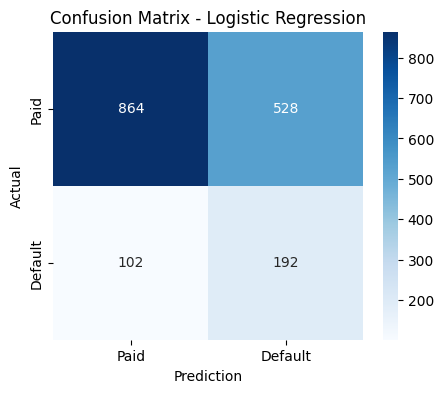

In [45]:
y_pred_lr=lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:,1]

print("LOGISTIC REGRESSION")
print(classification_report(y_test, y_pred_lr, target_names=["Paid", "Default"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

##CONFUSION MATRIX
cm= confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",cmap="Blues",
            xticklabels=["Paid", "Default"],
            yticklabels=["Paid", "Default"]            
            )
plt.title("Confusion Matrix - Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Prediction")
plt.tight_layout
plt.savefig("Chart_Confusion_Matrix.png", dpi=150)
plt.show()


TRAIN & EVALUATE RANDOM FORREST

In [46]:
rf_pipeline =   Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

rf_pipeline.fit(X_train,y_train)
print("Random forrest trained")

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:,1]

print("RANDOM FORREST")
print(classification_report(y_test, y_pred_rf, target_names=["Paid", "Default"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

Random forrest trained
RANDOM FORREST
              precision    recall  f1-score   support

        Paid       0.88      0.72      0.79      1392
     Default       0.29      0.54      0.38       294

    accuracy                           0.69      1686
   macro avg       0.58      0.63      0.58      1686
weighted avg       0.78      0.69      0.72      1686

ROC-AUC: 0.6957


ROC CURVE COMPARISON

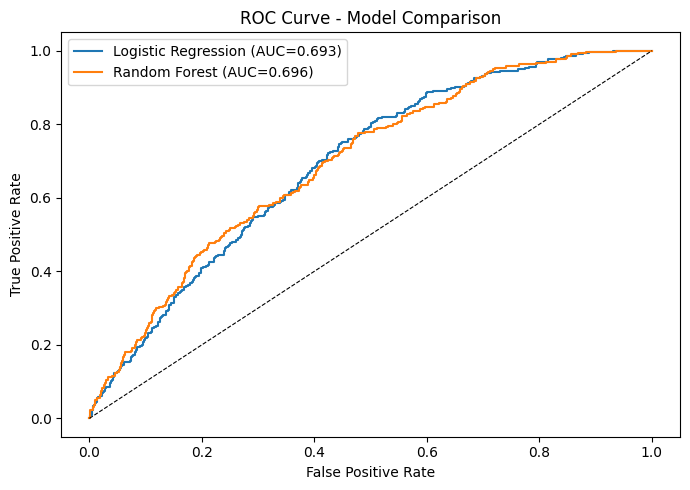

In [47]:
fpr_lr, tpr_lr,_ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf) 

plt.figure(figsize=(7,5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_score(y_test, y_prob_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label = f"Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.3f})")
plt.plot([0,1], [0,1], "k--", linewidth=0.8)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("Chart_roc_curve.png", dpi=150)
plt.show()

FEATURE IMPORTANCE

/var/folders/4s/phwctbwd5r39t7s2tmzqpt380000gn/T/ipykernel_1214/2452445269.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x="importance", y="feature", palette="viridis")


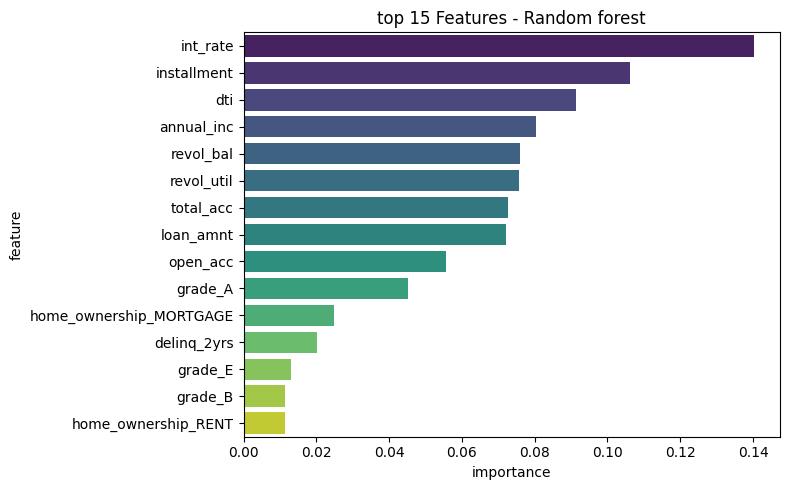

In [48]:
cat_feature_names = lr_pipeline.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(CATEGORICAL_FEATURES)
all_features = NUMERIC_FEATURES + list(cat_feature_names)
importances = rf_pipeline.named_steps["model"].feature_importances_

feat_df = pd.DataFrame({
    "feature": all_features,
    "importance": importances
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8,5))
sns.barplot(data=feat_df, x="importance", y="feature", palette="viridis")
plt.title("top 15 Features - Random forest")
plt.tight_layout()
plt.savefig("Chart_feature_importance.png", dpi=150)
plt.show()

Saving the best model

In [49]:
import joblib

joblib.dump(rf_pipeline, "model_credit_risk.pkl")
print("Model saved as model_credit_risk.pkl")

Model saved as model_credit_risk.pkl
